In [1]:
import pandas as pd

transactions = pd.read_excel('../data/QVI_transaction_data_1.xlsx')
customers = pd.read_csv('../data/QVI_purchase_behaviour_1.csv')
transactions['DATE'] = pd.to_datetime(transactions['DATE'], origin='1899-12-30', unit='D')
data = transactions.merge(customers, on='LYLTY_CARD_NBR', how='left')
chips_only = data[~data['PROD_NAME'].str.contains('salsa|dip', case=False, na=False)]

print(chips_only.shape)
chips_only.head()


(245304, 10)


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


In [2]:
print(chips_only['PROD_QTY'].describe())
print(chips_only.nlargest(5, 'PROD_QTY')[['LYLTY_CARD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES']])

count    245304.000000
mean          1.908200
std           0.661172
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64
       LYLTY_CARD_NBR                               PROD_NAME  PROD_QTY  \
69762          226000        Dorito Corn Chp     Supreme 380g       200   
69763          226000        Dorito Corn Chp     Supreme 380g       200   
3                2373  Smiths Chip Thinly  S/Cream&Onion 175g         5   
11               8294   Kettle Sensations   Siracha Lime 150g         5   
56              74336   GrnWves Plus Btroot & Chilli Jam 180g         5   

       TOT_SALES  
69762      650.0  
69763      650.0  
3           15.0  
11          23.0  
56          15.5  


In [3]:
print(chips_only[chips_only['LYLTY_CARD_NBR'] == 226000])

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES       LIFESTAGE  \
69762  Dorito Corn Chp     Supreme 380g       200      650.0  OLDER FAMILIES   
69763  Dorito Corn Chp     Supreme 380g       200      650.0  OLDER FAMILIES   

      PREMIUM_CUSTOMER  
69762          Premium  
69763          Premium  


In [8]:
chips_clean = chips_only[chips_only['LYLTY_CARD_NBR'] != 226000].copy()

total_sales = chips_clean['TOT_SALES'].sum()
unique_customers = chips_clean['LYLTY_CARD_NBR'].nunique()
avg_price = (chips_clean['TOT_SALES'] / chips_clean['PROD_QTY']).mean()

print(f"Total sales: ${total_sales:,.2f}")
print(f"Unique customers: {unique_customers}")
print(f"Average price per unit: ${avg_price:.2f}")

Total sales: $1,798,131.70
Unique customers: 71185
Average price per unit: $3.84


In [9]:
print("Total customers in customer file:", customers['LYLTY_CARD_NBR'].nunique())
print("Customers who bought chips:", chips_clean['LYLTY_CARD_NBR'].nunique())

Total customers in customer file: 72637
Customers who bought chips: 71185


In [10]:
print(chips_clean.nlargest(10, 'TOT_SALES')[['LYLTY_CARD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES']])

        LYLTY_CARD_NBR                               PROD_NAME  PROD_QTY  \
5179             94148  Smiths Crnkle Chip  Orgnl Big Bag 380g         5   
55558           190113  Smiths Crnkle Chip  Orgnl Big Bag 380g         5   
69496            49303  Smiths Crnkle Chip  Orgnl Big Bag 380g         5   
117850          194308  Smiths Crnkle Chip  Orgnl Big Bag 380g         5   
150683          118021  Smiths Crnkle Chip  Orgnl Big Bag 380g         5   
171815           24095  Smiths Crnkle Chip  Orgnl Big Bag 380g         5   
184969           44350  Smiths Crnkle Chip  Orgnl Big Bag 380g         5   
72               96203       Smiths Crinkle      Original 330g         5   
17110           172239       Smiths Crinkle      Original 330g         5   
32248            66014                    Cheezels Cheese 330g         5   

        TOT_SALES  
5179         29.5  
55558        29.5  
69496        29.5  
117850       29.5  
150683       29.5  
171815       29.5  
184969       29.5  
72 

In [11]:
chips_clean['YearMonth'] = chips_clean['DATE'].dt.to_period('M')
monthly_sales = chips_clean.groupby('YearMonth')['TOT_SALES'].sum()
print(monthly_sales)

YearMonth
2018-07    153874.90
2018-08    146850.05
2018-09    149507.70
2018-10    152905.50
2018-11    148907.50
2018-12    155871.40
2019-01    151016.60
2019-02    139941.80
2019-03    155216.40
2019-04    148734.60
2019-05    145762.15
2019-06    149543.10
Freq: M, Name: TOT_SALES, dtype: float64


In [12]:
avg_month = monthly_sales.mean()
dec_pct_diff = (monthly_sales['2018-12'] - avg_month) / avg_month * 100
print(f"Average month: ${avg_month:,.2f}")
print(f"December: ${monthly_sales['2018-12']:,.2f}")
print(f"December vs. average: {dec_pct_diff:.1f}%")

Average month: $149,844.31
December: $155,871.40
December vs. average: 4.0%


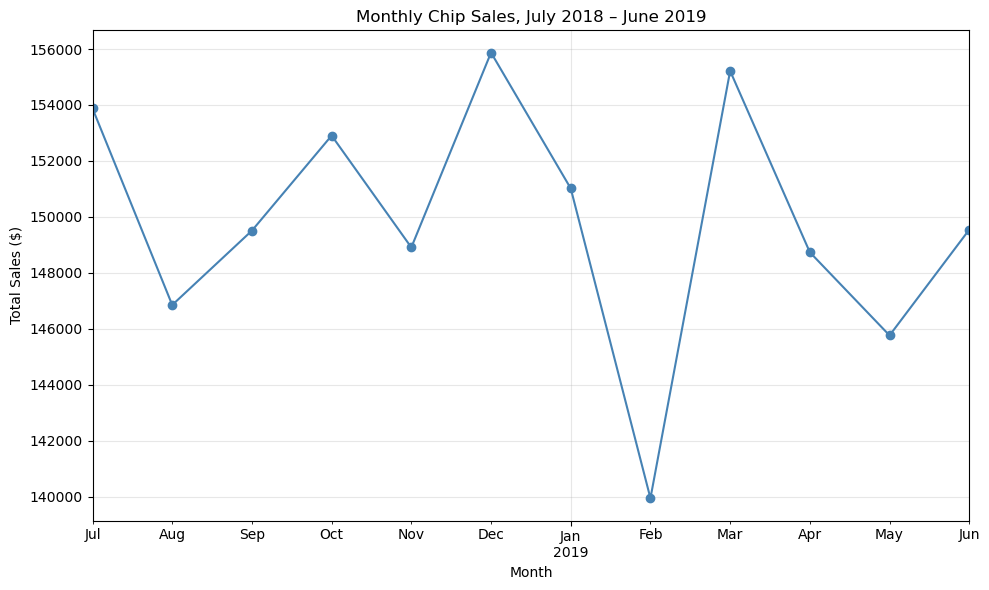

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Chip Sales, July 2018 – June 2019')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/01_monthly_sales.png', dpi=150)
plt.show()

In [14]:
segment_sales = chips_clean.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().sort_values(ascending=False)
print(segment_sales.head(10))

LIFESTAGE              PREMIUM_CUSTOMER
OLDER FAMILIES         Budget              156096.75
YOUNG SINGLES/COUPLES  Mainstream          147244.20
RETIREES               Mainstream          144677.55
YOUNG FAMILIES         Budget              129151.15
OLDER SINGLES/COUPLES  Budget              127279.80
                       Mainstream          124089.50
                       Premium             123147.55
RETIREES               Budget              105586.10
OLDER FAMILIES         Mainstream           96059.95
RETIREES               Premium              91013.25
Name: TOT_SALES, dtype: float64


<Figure size 1000x600 with 0 Axes>

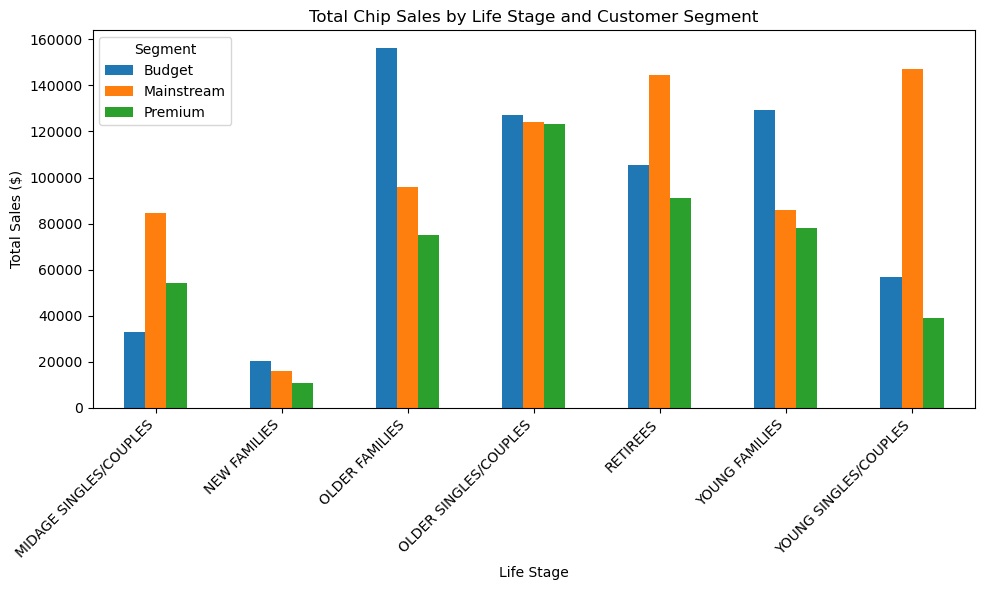

In [15]:
segment_pivot = chips_clean.pivot_table(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='TOT_SALES', aggfunc='sum')

plt.figure(figsize=(10, 6))
segment_pivot.plot(kind='bar', figsize=(10, 6))
plt.title('Total Chip Sales by Life Stage and Customer Segment')
plt.xlabel('Life Stage')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Segment')
plt.tight_layout()
plt.savefig('../images/02_segment_sales.png', dpi=150)
plt.show()

In [16]:
chips_clean['BRAND'] = chips_clean['PROD_NAME'].str.split().str[0]
print(chips_clean['BRAND'].value_counts().head(15))

BRAND
Kettle       41288
Smiths       25952
Pringles     25102
Doritos      22041
Thins        14075
RRD          11894
Infuzions    11057
WW           10320
Cobs          9693
Tostitos      9471
Twisties      9454
Tyrrells      6442
Grain         6272
Natural       6050
Cheezels      4603
Name: count, dtype: int64


In [18]:
brand_counts = chips_clean['BRAND'].value_counts()
print(brand_counts[brand_counts.index.str.contains('Dorito', case=False, na=False)])

BRAND
Doritos    22041
Dorito      3183
Name: count, dtype: int64


In [19]:
print(chips_clean[chips_clean['BRAND'] == 'Grain']['PROD_NAME'].unique())
print(chips_clean[chips_clean['BRAND'] == 'Natural']['PROD_NAME'].unique())

['Grain Waves         Sweet Chilli 210g'
 'Grain Waves Sour    Cream&Chives 210G']
['Natural Chip        Compny SeaSalt175g'
 'Natural ChipCo      Hony Soy Chckn175g'
 'Natural Chip Co     Tmato Hrb&Spce 175g'
 'Natural ChipCo Sea  Salt & Vinegr 175g']


In [20]:
brand_corrections = {
    'Dorito': 'Doritos',
    'Grain': 'Grain Waves',
    'Natural': 'Natural Chip Co',
    'NCC': 'Natural Chip Co',
    'WW': 'Woolworths',
    'RRD': 'Red Rock Deli'
}

chips_clean['BRAND'] = chips_clean['BRAND'].replace(brand_corrections)
print(chips_clean['BRAND'].value_counts())

BRAND
Kettle             41288
Smiths             25952
Doritos            25224
Pringles           25102
Thins              14075
Red Rock Deli      11894
Woolworths         11836
Infuzions          11057
Cobs                9693
Tostitos            9471
Twisties            9454
Natural Chip Co     7469
Tyrrells            6442
Grain Waves         6272
Cheezels            4603
CCs                 4551
Red                 4427
Infzns              3144
Smith               2963
Cheetos             2927
Snbts               1576
Burger              1564
GrnWves             1468
Sunbites            1432
French              1418
Name: count, dtype: int64


In [21]:
for brand in ['Red', 'Infzns', 'Smith', 'Snbts', 'Burger', 'GrnWves', 'French']:
    print(f"--- {brand} ---")
    print(chips_clean[chips_clean['BRAND'] == brand]['PROD_NAME'].unique())
    print()

--- Red ---
['Red Rock Deli Thai  Chilli&Lime 150g'
 'Red Rock Deli Sp    Salt & Truffle 150G'
 'Red Rock Deli Chikn&Garlic Aioli 150g']

--- Infzns ---
['Infzns Crn Crnchers Tangy Gcamole 110g']

--- Smith ---
['Smith Crinkle Cut   Mac N Cheese 150g'
 'Smith Crinkle Cut   Bolognese 150g']

--- Snbts ---
['Snbts Whlgrn Crisps Cheddr&Mstrd 90g']

--- Burger ---
['Burger Rings 220g']

--- GrnWves ---
['GrnWves Plus Btroot & Chilli Jam 180g']

--- French ---
['French Fries Potato Chips 175g']



In [22]:
brand_corrections_2 = {
    'Red': 'Red Rock Deli',
    'Infzns': 'Infuzions',
    'Smith': 'Smiths',
    'Snbts': 'Sunbites',
    'GrnWves': 'Grain Waves'
}

chips_clean['BRAND'] = chips_clean['BRAND'].replace(brand_corrections_2)
print(chips_clean['BRAND'].value_counts())

BRAND
Kettle             41288
Smiths             28915
Doritos            25224
Pringles           25102
Red Rock Deli      16321
Infuzions          14201
Thins              14075
Woolworths         11836
Cobs                9693
Tostitos            9471
Twisties            9454
Grain Waves         7740
Natural Chip Co     7469
Tyrrells            6442
Cheezels            4603
CCs                 4551
Sunbites            3008
Cheetos             2927
Burger              1564
French              1418
Name: count, dtype: int64


In [23]:
brand_revenue = chips_clean.groupby('BRAND')['TOT_SALES'].sum().sort_values(ascending=False)
brand_share = (brand_revenue / brand_revenue.sum() * 100).round(1)
print(brand_share.head(10))

BRAND
Kettle           21.7
Doritos          12.6
Smiths           11.7
Pringles          9.9
Infuzions         5.5
Thins             4.9
Red Rock Deli     4.9
Twisties          4.5
Tostitos          4.4
Cobs              3.9
Name: TOT_SALES, dtype: float64


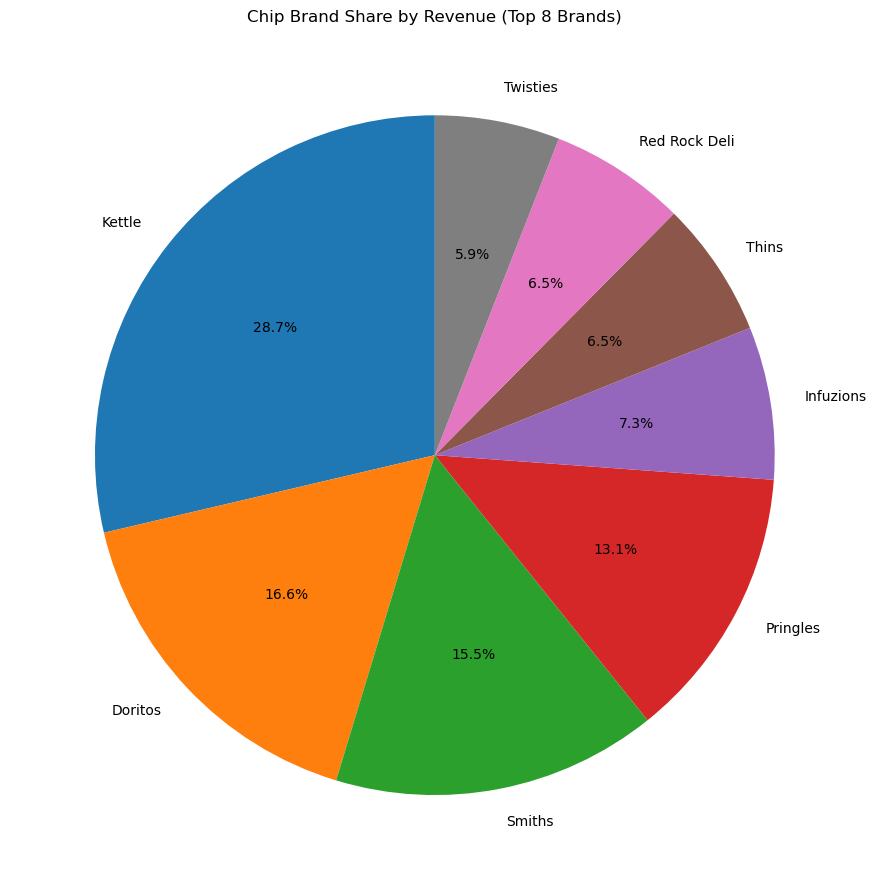

In [24]:
top_brands = brand_share.head(8)

plt.figure(figsize=(9, 9))
plt.pie(top_brands, labels=top_brands.index, autopct='%1.1f%%', startangle=90)
plt.title('Chip Brand Share by Revenue (Top 8 Brands)')
plt.tight_layout()
plt.savefig('../images/03_brand_share.png', dpi=150)
plt.show()

In [25]:
chips_clean['YearMonth'] = chips_clean['DATE'].dt.to_period('M')

store_metrics = chips_clean.groupby(['STORE_NBR', 'YearMonth']).agg(
    total_sales=('TOT_SALES', 'sum'),
    unique_customers=('LYLTY_CARD_NBR', 'nunique'),
    total_transactions=('TXN_ID', 'nunique')
).reset_index()

store_metrics['txns_per_customer'] = store_metrics['total_transactions'] / store_metrics['unique_customers']

print(store_metrics.shape)
store_metrics.head(10)

(3165, 6)


,STORE_NBR,YearMonth,total_sales,unique_customers,total_transactions,txns_per_customer
0,1,2018-07,188.9,47,49,1.042553
1,1,2018-08,168.4,41,41,1.000000
2,1,2018-09,268.1,57,59,1.035088
3,1,2018-10,175.4,39,40,1.025641
4,1,2018-11,184.8,44,45,1.022727
5,1,2018-12,160.6,37,40,1.081081
6,1,2019-01,144.5,33,33,1.000000
7,1,2019-02,192.1,48,50,1.041667
8,1,2019-03,185.2,43,47,1.093023
9,1,2019-04,177.4,39,40,1.025641


In [26]:
pre_trial_months = ['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01']

store_month_counts = store_metrics[store_metrics['YearMonth'].astype(str).isin(pre_trial_months)].groupby('STORE_NBR').size()

eligible_stores = store_month_counts[store_month_counts == 7].index
print("Eligible stores:", len(eligible_stores))

Eligible stores: 260


In [27]:
pre_trial_data = store_metrics[
    (store_metrics['YearMonth'].astype(str).isin(pre_trial_months)) &
    (store_metrics['STORE_NBR'].isin(eligible_stores))
]

print(pre_trial_data.shape)

(1820, 6)


In [28]:
sales_pivot = pre_trial_data.pivot(index='STORE_NBR', columns='YearMonth', values='total_sales')
customers_pivot = pre_trial_data.pivot(index='STORE_NBR', columns='YearMonth', values='unique_customers')

print(sales_pivot.shape)
sales_pivot.head()

(260, 7)


YearMonth,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01
STORE_NBR,,,,,,,
1,188.9,168.40,268.1,175.4,184.8,160.6,144.5
2,137.9,180.90,133.9,160.1,143.3,129.2,158.7
3,1164.9,998.15,1011.3,1017.5,936.6,1075.7,980.3
4,1318.3,1188.10,1168.0,1275.0,1089.6,1134.6,1402.6
5,763.8,644.10,854.4,735.4,701.8,795.0,767.4


In [30]:
import numpy as np

def calculate_similarity(trial_store, pivot_table):
    trial_series = pivot_table.loc[trial_store]
    scores = {}
    
    for store in pivot_table.index:
        if store == trial_store:
            continue
        other_series = pivot_table.loc[store]
        
        correlation = trial_series.corr(other_series)
        
        magnitude_distance = abs(trial_series - other_series).mean()
        max_dist = abs(trial_series.values[:, None] - pivot_table.values).mean()
        normalized_magnitude = 1 - (magnitude_distance / max_dist)
        
        composite = 0.5 * correlation + 0.5 * normalized_magnitude
        scores[store] = composite
    
    return pd.Series(scores).sort_values(ascending=False)

In [31]:
sales_scores_77 = calculate_similarity(77, sales_pivot)
print(sales_scores_77.head(10))

ValueError: operands could not be broadcast together with shapes (7,1) (260,7) 

In [32]:
def calculate_similarity(trial_store, pivot_table):
    trial_series = pivot_table.loc[trial_store]
    scores = {}
    
    all_distances = abs(pivot_table.values - trial_series.values).mean()
    
    for store in pivot_table.index:
        if store == trial_store:
            continue
        other_series = pivot_table.loc[store]
        
        correlation = trial_series.corr(other_series)
        magnitude_distance = abs(trial_series - other_series).mean()
        normalized_magnitude = 1 - (magnitude_distance / all_distances)
        
        composite = 0.5 * correlation + 0.5 * normalized_magnitude
        scores[store] = composite
    
    return pd.Series(scores).sort_values(ascending=False)

In [33]:
sales_scores_77 = calculate_similarity(77, sales_pivot)
print(sales_scores_77.head(10))

233    0.952473
50     0.900553
167    0.776972
53     0.762344
41     0.739629
188    0.721739
35     0.697009
195    0.685687
115    0.682451
20     0.680265
dtype: float64


In [34]:
sales_scores_86 = calculate_similarity(86, sales_pivot)
sales_scores_88 = calculate_similarity(88, sales_pivot)

print("Store 86 top matches:")
print(sales_scores_86.head(5))
print("\nStore 88 top matches:")
print(sales_scores_88.head(5))

Store 86 top matches:
155    0.869234
138    0.818955
222    0.791878
114    0.790137
269    0.765776
dtype: float64

Store 88 top matches:
79     0.660311
7      0.650078
91     0.639648
201    0.628519
217    0.597549
dtype: float64


In [35]:
print("Store 237's rank and score for trial store 88:")
print(sales_scores_88.get(237, "Not found"))
print(sales_scores_88.rank(ascending=False)[237] if 237 in sales_scores_88.index else "Store 237 not in results")

Store 237's rank and score for trial store 88:
0.5027010658607092
12.0


In [36]:
def calculate_combined_similarity(trial_store, sales_pivot, customers_pivot):
    sales_scores = calculate_similarity(trial_store, sales_pivot)
    customer_scores = calculate_similarity(trial_store, customers_pivot)
    
    combined = (sales_scores + customer_scores) / 2
    return combined.sort_values(ascending=False)

combined_88 = calculate_combined_similarity(88, sales_pivot, customers_pivot)
print(combined_88.head(10))

237    0.729238
123    0.633693
201    0.594670
7      0.570781
238    0.529892
79     0.527581
178    0.525071
69     0.497740
95     0.488076
106    0.481498
dtype: float64


In [37]:
combined_77 = calculate_combined_similarity(77, sales_pivot, customers_pivot)
combined_86 = calculate_combined_similarity(86, sales_pivot, customers_pivot)

print("Store 77 (combined):")
print(combined_77.head(5))
print("\nStore 86 (combined):")
print(combined_86.head(5))

Store 77 (combined):
233    0.953992
50     0.818722
167    0.771782
53     0.761920
35     0.761399
dtype: float64

Store 86 (combined):
155    0.868862
114    0.823358
138    0.750300
225    0.685561
269    0.682428
dtype: float64


In [38]:
def get_scaling_factor(trial_store, control_store, pivot_table, pre_trial_months):
    trial_pretrial = pivot_table.loc[trial_store, pre_trial_months]
    control_pretrial = pivot_table.loc[control_store, pre_trial_months]
    return trial_pretrial.mean() / control_pretrial.mean()

scaling_77 = get_scaling_factor(77, 233, sales_pivot, pre_trial_months)
print("Store 77/233 sales scaling factor:", round(scaling_77, 3))

Store 77/233 sales scaling factor: 1.051


In [40]:
full_sales_pivot = store_metrics.pivot(index='STORE_NBR', columns='YearMonth', values='total_sales')
full_customers_pivot = store_metrics.pivot(index='STORE_NBR', columns='YearMonth', values='unique_customers')

full_sales_pivot.columns = full_sales_pivot.columns.astype(str)
full_customers_pivot.columns = full_customers_pivot.columns.astype(str)

print(full_sales_pivot.shape)
print(full_sales_pivot.columns.tolist())

(271, 12)
['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06']


In [41]:
sales_ttest_77 = run_uplift_test(77, 233, full_sales_pivot, pre_trial_months, trial_months)
print("Store 77 sales t-values:", sales_ttest_77)

Store 77 sales t-values: {'2019-02': np.float64(-0.9), '2019-03': np.float64(2.9), '2019-04': np.float64(4.5)}


In [42]:
def run_uplift_test_v2(trial_store, control_store, pivot_table, pre_trial_months, trial_months):
    scaling_factor = get_scaling_factor(trial_store, control_store, pivot_table, pre_trial_months)
    
    trial_pretrial = pivot_table.loc[trial_store, pre_trial_months]
    control_pretrial_scaled = pivot_table.loc[control_store, pre_trial_months] * scaling_factor
    pretrial_diffs = trial_pretrial - control_pretrial_scaled
    std_dev = pretrial_diffs.std(ddof=0)  # population std instead of sample std
    
    results = {}
    for month in trial_months:
        trial_actual = pivot_table.loc[trial_store, month]
        control_scaled = pivot_table.loc[control_store, month] * scaling_factor
        diff = trial_actual - control_scaled
        t_value = diff / std_dev
        results[month] = round(t_value, 1)
    
    return results

sales_ttest_77_v2 = run_uplift_test_v2(77, 233, full_sales_pivot, pre_trial_months, trial_months)
print("Store 77 sales t-values (population std):", sales_ttest_77_v2)

Store 77 sales t-values (population std): {'2019-02': np.float64(-0.9), '2019-03': np.float64(3.1), '2019-04': np.float64(4.9)}


In [43]:
def run_uplift_test_v3(trial_store, control_store, pivot_table, pre_trial_months, trial_months):
    scaling_factor = get_scaling_factor(trial_store, control_store, pivot_table, pre_trial_months)
    
    trial_pretrial = pivot_table.loc[trial_store, pre_trial_months]
    control_pretrial_scaled = pivot_table.loc[control_store, pre_trial_months] * scaling_factor
    pretrial_pct_diffs = (trial_pretrial - control_pretrial_scaled) / control_pretrial_scaled
    std_dev = pretrial_pct_diffs.std()
    
    results = {}
    for month in trial_months:
        trial_actual = pivot_table.loc[trial_store, month]
        control_scaled = pivot_table.loc[control_store, month] * scaling_factor
        pct_diff = (trial_actual - control_scaled) / control_scaled
        t_value = pct_diff / std_dev
        results[month] = round(t_value, 1)
    
    return results

sales_ttest_77_v3 = run_uplift_test_v3(77, 233, full_sales_pivot, pre_trial_months, trial_months)
print("Store 77 sales t-values (percentage-based):", sales_ttest_77_v3)

Store 77 sales t-values (percentage-based): {'2019-02': np.float64(-0.7), '2019-03': np.float64(3.1), '2019-04': np.float64(5.9)}


In [44]:
control_map = {77: 233, 86: 155, 88: 237}

all_results = {}
for trial, control in control_map.items():
    sales_result = run_uplift_test(trial, control, full_sales_pivot, pre_trial_months, trial_months)
    cust_result = run_uplift_test(trial, control, full_customers_pivot, pre_trial_months, trial_months)
    all_results[trial] = {'sales': sales_result, 'customers': cust_result}

for trial, results in all_results.items():
    print(f"Trial Store {trial} (Control {control_map[trial]}):")
    print(f"  Sales t-values: {results['sales']}")
    print(f"  Customer t-values: {results['customers']}")
    print()

Trial Store 77 (Control 233):
  Sales t-values: {'2019-02': np.float64(-0.9), '2019-03': np.float64(2.9), '2019-04': np.float64(4.5)}
  Customer t-values: {'2019-02': np.float64(-1.8), '2019-03': np.float64(6.1), '2019-04': np.float64(10.6)}

Trial Store 86 (Control 155):
  Sales t-values: {'2019-02': np.float64(1.2), '2019-03': np.float64(5.1), '2019-04': np.float64(0.6)}
  Customer t-values: {'2019-02': np.float64(3.8), '2019-03': np.float64(5.0), '2019-04': np.float64(1.4)}

Trial Store 88 (Control 237):
  Sales t-values: {'2019-02': np.float64(0.4), '2019-03': np.float64(3.1), '2019-04': np.float64(1.8)}
  Customer t-values: {'2019-02': np.float64(1.0), '2019-03': np.float64(5.0), '2019-04': np.float64(1.0)}



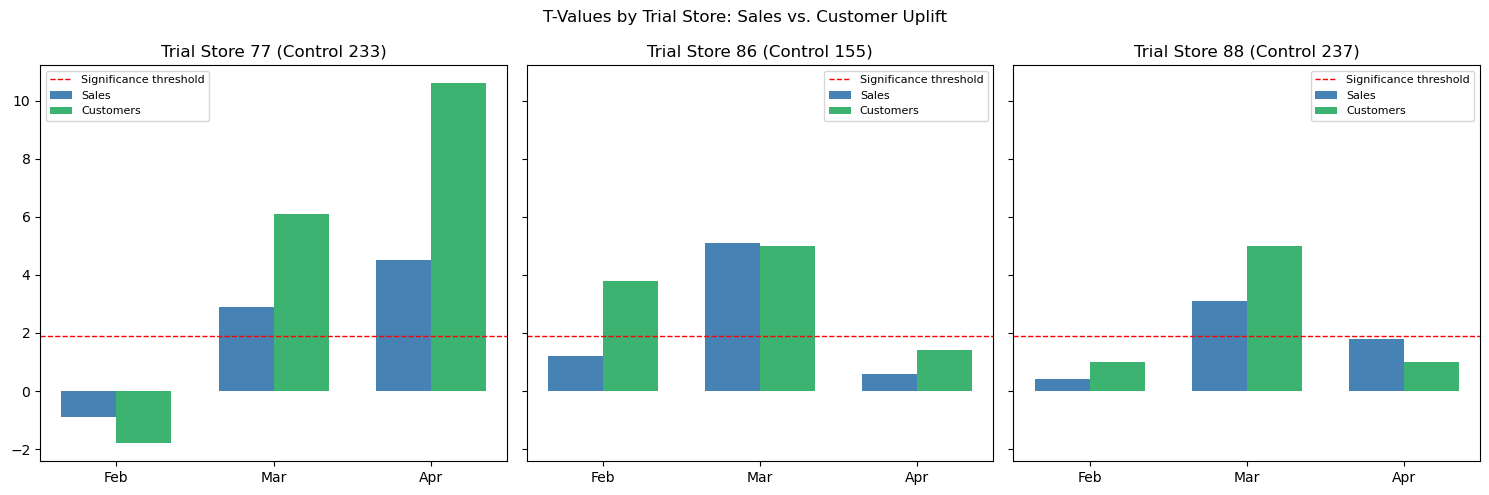

In [45]:
import numpy as np

stores = [77, 86, 88]
months_labels = ['Feb', 'Mar', 'Apr']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, store in enumerate(stores):
    sales_vals = list(all_results[store]['sales'].values())
    cust_vals = list(all_results[store]['customers'].values())
    
    x = np.arange(len(months_labels))
    width = 0.35
    
    axes[i].bar(x - width/2, sales_vals, width, label='Sales', color='steelblue')
    axes[i].bar(x + width/2, cust_vals, width, label='Customers', color='mediumseagreen')
    axes[i].axhline(1.895, color='red', linestyle='--', linewidth=1, label='Significance threshold')
    axes[i].set_title(f'Trial Store {store} (Control {control_map[store]})')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(months_labels)
    axes[i].legend(fontsize=8)

plt.suptitle('T-Values by Trial Store: Sales vs. Customer Uplift')
plt.tight_layout()
plt.savefig('../images/04_uplift_ttest_summary.png', dpi=150)
plt.show()